# 05 — Modelo Baseline (media móvil 4 semanas)

**Objetivo:** Construir un modelo de referencia simple para evaluar el aporte de los modelos sofisticados (LightGBM, XGBoost, Prophet).

**Fase CRISP-DM:** 4 — Modelado (primer modelo, baseline).

**Inputs:**
- `data/processed/dataset_modelable.parquet` (generado en notebook 03)
- Tabla `clasificacion_abc_xyz` (generada en notebook 04)

**Outputs:**
- Métricas del baseline guardadas en MySQL (tabla `metricas_modelos`).
- Predicciones del baseline en MySQL (tabla `pronosticos`).
- Visualizaciones comparativas en `reports/figures/baseline/`.

**¿Por qué un baseline?**

Sin baseline no es posible afirmar que un modelo complejo "es bueno". El baseline es la línea base contra la cual se mide el aporte real de los modelos avanzados.

**Si LightGBM mejora al baseline → demuestra valor metodológico.**
**Si LightGBM no mejora al baseline → el problema no requiere modelos complejos.**

Ambas conclusiones son válidas y se reportan honestamente.

**Definición del baseline:**

Para predecir la cantidad de un SKU × centro × semana W:

$$\hat{y}_W = \frac{1}{4}\sum_{i=1}^{4} y_{W-i}$$

Es decir, el promedio de las últimas 4 semanas. Esto ya está calculado como feature `rolling_mean_4` en el dataset modelable.

**Autor:** Equipo del proyecto — Diego Andrés De Jesús Montenegro y Luis David Andrade Díaz
**Fecha:** mayo 2026

In [1]:
# =========================
# Imports
# =========================
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import text

from src.db import get_engine

# Configuracion visual
COLOR_PRIMARIO = "#1F4E78"
COLOR_SECUNDARIO = "#E67E22"
COLOR_VERDE = "#27AE60"
COLOR_ROJO = "#C0392B"

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FIG_DIR = ROOT / "reports" / "figures" / "baseline"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    out = FIG_DIR / f"{nombre}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"  Guardado: {out.relative_to(ROOT)}")

print("Setup completado.")

Setup completado.


## 1. Carga del dataset modelable

In [2]:
# Cargar el dataset modelable (generado en notebook 03)
ruta_parquet = ROOT / "data" / "processed" / "dataset_modelable.parquet"
dataset = pd.read_parquet(ruta_parquet)

print(f"Dataset cargado: {len(dataset):,} filas x {len(dataset.columns)} columnas")
print(f"Splits disponibles:")
print(dataset["split"].value_counts())

Dataset cargado: 517,846 filas x 40 columnas
Splits disponibles:
split
train        386661
test_2026     66572
valid         64613
Name: count, dtype: int64


In [3]:
# Cargar la clasificacion ABC/XYZ desde MySQL (para reportes por segmento)
engine = get_engine()
clasif = pd.read_sql(
    "SELECT item, clase_abc, segmento_abc_xyz FROM clasificacion_abc_xyz",
    engine,
)
print(f"Clasificacion cargada: {len(clasif):,} SKUs con clase ABC/XYZ")

Clasificacion cargada: 2,380 SKUs con clase ABC/XYZ


## 2. Implementación del baseline

El baseline es directamente la columna `rolling_mean_4` que ya calculamos en el notebook 03. Para cada fila, esa columna contiene el promedio de las **4 semanas anteriores** (excluyendo la actual, gracias al `shift(1)` que aplicamos).

In [4]:
# La prediccion del baseline ya esta calculada: es rolling_mean_4
dataset["y_real"] = dataset["cantidad_total"]
dataset["y_pred_baseline"] = dataset["rolling_mean_4"]

# Estadisticas iniciales
print("Predicciones del baseline:")
print(dataset["y_pred_baseline"].describe())

Predicciones del baseline:
count   517,846.0000
mean         44.3102
std         568.7070
min           0.0000
25%           0.0000
50%           0.2500
75%           2.7500
max      33,113.0000
Name: y_pred_baseline, dtype: float64


## 3. Manejo de predicciones inválidas

Aplicamos `np.clip` para evitar predicciones negativas (no tienen sentido físico — no puedes vender -3 sacos de cemento).

In [5]:
# Aplicar clip a 0 (no hay cantidades negativas)
dataset["y_pred_baseline"] = dataset["y_pred_baseline"].clip(lower=0)

# Las primeras semanas de cada SKU tendran rolling_mean_4 = 0 (porque se rellenaron con 0)
# Eso es aceptable: predecimos cero cuando no hay historia
print(f"Predicciones negativas tras clip: {(dataset['y_pred_baseline'] < 0).sum()}")
print(f"Predicciones cero: {(dataset['y_pred_baseline'] == 0).sum():,}")
print(f"Predicciones positivas: {(dataset['y_pred_baseline'] > 0).sum():,}")

Predicciones negativas tras clip: 0
Predicciones cero: 233,681
Predicciones positivas: 284,165


## 4. Función de métricas

Definimos una función reutilizable que calcula MAE, RMSE, MAPE y sMAPE. Esta función la usaremos también en los notebooks 06, 07, 08 y 09.

In [6]:
def calcular_metricas(y_real, y_pred, nombre=""):
    """Calcula MAE, RMSE, MAPE y sMAPE.

    Args:
        y_real: valores reales (numpy array o pd.Series)
        y_pred: valores predichos
        nombre: etiqueta para imprimir

    Returns:
        dict con las metricas
    """
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_real - y_pred
    abs_error = np.abs(error)

    mae = abs_error.mean()
    rmse = np.sqrt((error ** 2).mean())

    # MAPE: solo donde y_real != 0
    mask_no_cero = y_real > 0
    if mask_no_cero.sum() > 0:
        mape = (abs_error[mask_no_cero] / y_real[mask_no_cero]).mean() * 100
    else:
        mape = np.nan

    # sMAPE: variante simetrica, robusta a ceros
    denominador = (np.abs(y_real) + np.abs(y_pred)) / 2
    mask_no_cero_smape = denominador > 0
    if mask_no_cero_smape.sum() > 0:
        smape = (abs_error[mask_no_cero_smape] / denominador[mask_no_cero_smape]).mean() * 100
    else:
        smape = np.nan

    metricas = {
        "n_obs": len(y_real),
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "smape": smape,
    }

    if nombre:
        print(f"{nombre}:")
        print(f"  N observaciones: {metricas['n_obs']:>10,}")
        print(f"  MAE:             {metricas['mae']:>10.4f}")
        print(f"  RMSE:            {metricas['rmse']:>10.4f}")
        print(f"  MAPE:            {metricas['mape']:>10.2f}%")
        print(f"  sMAPE:           {metricas['smape']:>10.2f}%")

    return metricas

print("Funcion calcular_metricas() lista.")

Funcion calcular_metricas() lista.


## 5. Métricas globales en Validation

El set de validación cubre 13 semanas de octubre a diciembre de 2025.

In [7]:
# Subset de validation
valid = dataset[dataset["split"] == "valid"].copy()
print(f"Validation: {len(valid):,} observaciones")
print(f"Periodo: {valid['fecha_inicio_semana'].min().date()} -> {valid['fecha_inicio_semana'].max().date()}")
print()

metricas_valid = calcular_metricas(
    valid["y_real"], valid["y_pred_baseline"],
    nombre="BASELINE EN VALIDATION (2025-Q4)"
)

Validation: 64,613 observaciones
Periodo: 2025-10-06 -> 2025-12-29

BASELINE EN VALIDATION (2025-Q4):
  N observaciones:     64,613
  MAE:                37.0883
  RMSE:              494.2920
  MAPE:                180.43%
  sMAPE:               146.32%


## 6. Métricas globales en Test 2026

El conjunto de test 2026 es la prueba "out of sample real": son datos posteriores al periodo de entrenamiento que el modelo nunca vio.

In [8]:
# Subset de test 2026
test_2026 = dataset[dataset["split"] == "test_2026"].copy()
print(f"Test 2026: {len(test_2026):,} observaciones")
print(f"Periodo: {test_2026['fecha_inicio_semana'].min().date()} -> {test_2026['fecha_inicio_semana'].max().date()}")
print()

metricas_test = calcular_metricas(
    test_2026["y_real"], test_2026["y_pred_baseline"],
    nombre="BASELINE EN TEST 2026 (out of sample)"
)

Test 2026: 66,572 observaciones
Periodo: 2026-01-05 -> 2026-03-30

BASELINE EN TEST 2026 (out of sample):
  N observaciones:     66,572
  MAE:                32.4968
  RMSE:              389.0088
  MAPE:                170.62%
  sMAPE:               147.72%


In [9]:
# Comparacion lado a lado
print("=" * 50)
print("COMPARACION VALIDATION vs TEST 2026")
print("=" * 50)
print(f"{'Metrica':<10} {'Valid':>15} {'Test 2026':>15}")
print("-" * 50)
for m in ["mae", "rmse", "mape", "smape"]:
    sufijo = "%" if m in ["mape", "smape"] else ""
    print(f"{m.upper():<10} {metricas_valid[m]:>15.4f}{sufijo:<1} {metricas_test[m]:>15.4f}{sufijo}")
print("=" * 50)
print("\nInterpretacion: si MAE de test es similar a valid, el modelo generaliza bien.")
print("Si MAE de test >> MAE de valid, hay un cambio de regimen en 2026 que el modelo no captura.")

COMPARACION VALIDATION vs TEST 2026
Metrica              Valid       Test 2026
--------------------------------------------------
MAE                37.0883          32.4968
RMSE              494.2920         389.0088
MAPE              180.4292%        170.6220%
SMAPE             146.3193%        147.7178%

Interpretacion: si MAE de test es similar a valid, el modelo generaliza bien.
Si MAE de test >> MAE de valid, hay un cambio de regimen en 2026 que el modelo no captura.


## 7. Métricas por segmento ABC

¿El baseline se comporta igual para SKUs grandes (A) que para SKUs pequeños (C)?

In [12]:
# Merge con clasificacion ABC
# Primero quitamos las columnas duplicadas que ya trae el dataset modelable
# (clase_abc y clase_xyz se crearon como features en el notebook 03)
cols_a_quitar = ["clase_abc", "clase_xyz", "segmento_abc_xyz"]

valid_sin_clase = valid.drop(columns=[c for c in cols_a_quitar if c in valid.columns])
test_sin_clase = test_2026.drop(columns=[c for c in cols_a_quitar if c in test_2026.columns])

# Ahora si hacemos el merge limpio
valid_clas = valid_sin_clase.merge(clasif, on="item", how="left")
test_clas = test_sin_clase.merge(clasif, on="item", how="left")

# Verificar que tenemos las columnas necesarias
print("Columnas de clasificacion despues del merge:")
print([c for c in valid_clas.columns if "clase" in c.lower() or "segmento" in c.lower()])
print(f"\nFilas con clase_abc nula: {valid_clas['clase_abc'].isna().sum()}")
print(f"Filas con segmento_abc_xyz nula: {valid_clas['segmento_abc_xyz'].isna().sum()}")

Columnas de clasificacion despues del merge:
['clase_abc_num', 'clase_xyz_num', 'clase_abc', 'segmento_abc_xyz']

Filas con clase_abc nula: 4524
Filas con segmento_abc_xyz nula: 4524


In [15]:
# Para SKUs sin clasificacion oficial (productos que activaron en 2026
# pero no estuvieron activos al cierre de 2025), asignar clase C / segmento CZ
valid_clas["clase_abc"] = valid_clas["clase_abc"].fillna("C")
valid_clas["segmento_abc_xyz"] = valid_clas["segmento_abc_xyz"].fillna("CZ")

test_clas["clase_abc"] = test_clas["clase_abc"].fillna("C")
test_clas["segmento_abc_xyz"] = test_clas["segmento_abc_xyz"].fillna("CZ")

# Verificar
print(f"Filas con clase_abc nula en valid: {valid_clas['clase_abc'].isna().sum()}")
print(f"Filas con clase_abc nula en test:  {test_clas['clase_abc'].isna().sum()}")
print(f"\nDistribucion final clase_abc en valid:")
print(valid_clas['clase_abc'].value_counts())

Filas con clase_abc nula en valid: 0
Filas con clase_abc nula en test:  0

Distribucion final clase_abc en valid:
clase_abc
C    48728
B    12557
A     3328
Name: count, dtype: int64


In [13]:
print("Test 2026 por clase ABC:")
metricas_abc_test = metricas_por_grupo(test_clas, "clase_abc")
metricas_abc_test

Test 2026 por clase ABC:


,n_obs,mae,rmse,mape,smape
clase_abc,,,,,
A,3328,211.9739,762.4183,245.3681,113.8523
B,12571,76.5505,773.6040,195.1372,128.0986
C,44863,10.7662,117.1405,151.9728,154.3903


In [14]:
# Verificar hipotesis: cuantos SKUs sin clasificacion hay
skus_sin_clase_valid = valid_clas[valid_clas["clase_abc"].isna()]["item"].unique()
skus_sin_clase_test = test_clas[test_clas["clase_abc"].isna()]["item"].unique()

print(f"SKUs distintos en valid sin clasificacion: {len(skus_sin_clase_valid)}")
print(f"SKUs distintos en test sin clasificacion:  {len(skus_sin_clase_test)}")

# Ver algunos ejemplos
print("\nEjemplos de SKUs sin clasificacion (primeros 10):")
print(skus_sin_clase_valid[:10])

# Tamano total de la clasificacion
print(f"\nSKUs totales en tabla clasificacion_abc_xyz: {len(clasif):,}")
print(f"SKUs totales en dataset modelable (parquet): {dataset['item'].nunique():,}")

SKUs distintos en valid sin clasificacion: 212
SKUs distintos en test sin clasificacion:  356

Ejemplos de SKUs sin clasificacion (primeros 10):
['000034' '000095' '000169' '000209' '000232' '000238' '000246' '000330'
 '000443' '000446']

SKUs totales en tabla clasificacion_abc_xyz: 2,380
SKUs totales en dataset modelable (parquet): 2,310


## 8. Métricas por matriz ABC × XYZ (9 segmentos)

Esta es la vista más informativa: ¿el baseline funciona mejor para ciertos tipos de SKU?

In [16]:
# Pivot table de MAE por segmento
def matriz_metrica(df, metrica="mae"):
    """Construye una pivot 3x3 ABC x XYZ con la metrica dada."""
    resultados = []
    for seg, sub in df.groupby("segmento_abc_xyz", observed=True):
        m = calcular_metricas(sub["y_real"], sub["y_pred_baseline"])
        clase_abc = seg[0]
        clase_xyz = seg[1]
        resultados.append({
            "clase_abc": clase_abc,
            "clase_xyz": clase_xyz,
            "metrica": m[metrica],
            "n_obs": m["n_obs"],
        })

    df_res = pd.DataFrame(resultados)
    matriz = df_res.pivot(index="clase_abc", columns="clase_xyz", values="metrica")
    matriz = matriz.reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"])
    return matriz

mae_matriz_valid = matriz_metrica(valid_clas, "mae")
mae_matriz_test = matriz_metrica(test_clas, "mae")

print("MAE en VALIDATION por segmento ABC x XYZ:")
print(mae_matriz_valid.round(2))
print("\nMAE en TEST 2026 por segmento ABC x XYZ:")
print(mae_matriz_test.round(2))

MAE en VALIDATION por segmento ABC x XYZ:
clase_xyz        X        Y        Z
clase_abc                           
A         368.6700 294.8500 226.9600
B         849.6300  69.0000  25.7400
C          16.8300  33.6900   6.6400

MAE en TEST 2026 por segmento ABC x XYZ:
clase_xyz        X        Y        Z
clase_abc                           
A         323.3500 231.0500 175.5800
B         776.4500  73.8000  22.4500
C          17.2600  32.8600   6.6500


  Guardado: reports/figures/baseline/01_mae_por_segmento.png


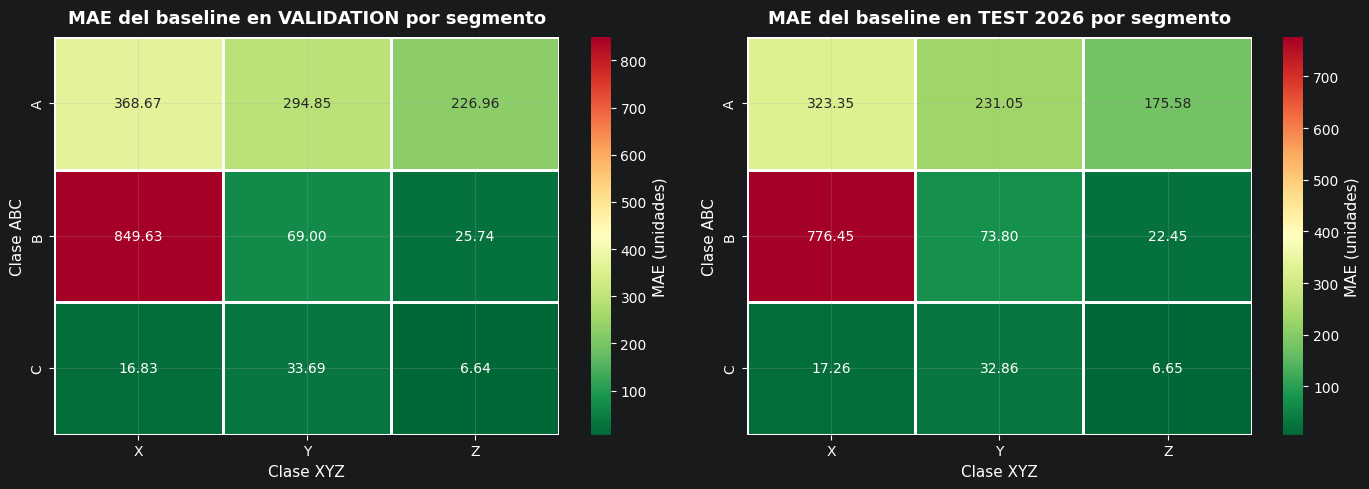


Interpretacion: numeros mas BAJOS = mejor desempeno (menos error).
Segmento AX/AY deberian tener MAE bajo (estables y predecibles).
Segmento AZ/CZ pueden tener MAE alto (erraticos y dificiles).


In [17]:
# Visualizacion: heatmap del MAE por segmento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(mae_matriz_valid, annot=True, fmt=".2f", cmap="RdYlGn_r",
            ax=axes[0], cbar_kws={"label": "MAE (unidades)"}, linewidths=1)
axes[0].set_title("MAE del baseline en VALIDATION por segmento", pad=10)
axes[0].set_xlabel("Clase XYZ")
axes[0].set_ylabel("Clase ABC")

sns.heatmap(mae_matriz_test, annot=True, fmt=".2f", cmap="RdYlGn_r",
            ax=axes[1], cbar_kws={"label": "MAE (unidades)"}, linewidths=1)
axes[1].set_title("MAE del baseline en TEST 2026 por segmento", pad=10)
axes[1].set_xlabel("Clase XYZ")
axes[1].set_ylabel("Clase ABC")

plt.tight_layout()
guardar(fig, "01_mae_por_segmento")
plt.show()

print("\nInterpretacion: numeros mas BAJOS = mejor desempeno (menos error).")
print("Segmento AX/AY deberian tener MAE bajo (estables y predecibles).")
print("Segmento AZ/CZ pueden tener MAE alto (erraticos y dificiles).")

## 9. Métricas por centro de operación

In [18]:
# Validation
print("Metricas por centro en VALIDATION:")
metricas_centro_valid = metricas_por_grupo(valid_clas, "centro_operacion")
print(metricas_centro_valid)
print()
print("Metricas por centro en TEST 2026:")
metricas_centro_test = metricas_por_grupo(test_clas, "centro_operacion")
print(metricas_centro_test)

Metricas por centro en VALIDATION:
                  n_obs     mae     rmse     mape    smape
centro_operacion                                          
001               24606 36.2656 466.6886 158.8060 138.6511
002               24345 56.0060 651.7707 198.6708 144.4864
003               15662  8.9750  73.8958 204.3610 171.7459

Metricas por centro en TEST 2026:
                  n_obs     mae     rmse     mape    smape
centro_operacion                                          
001               25369 33.0035 424.1650 145.8146 139.2043
002               24907 46.0403 461.2382 189.8582 146.3670
003               16296 11.0078 113.8371 201.3811 172.9666


## 10. Análisis de residuales

Los residuales (errores) deberían distribuirse alrededor de 0. Si hay sesgo sistemático, el modelo sub- o sobre-predice consistentemente.

In [19]:
# Calcular residuales = real - prediccion
valid["residual"] = valid["y_real"] - valid["y_pred_baseline"]
test_2026["residual"] = test_2026["y_real"] - test_2026["y_pred_baseline"]

print("Residuales en VALIDATION:")
print(valid["residual"].describe())
print()
print("Residuales en TEST 2026:")
print(test_2026["residual"].describe())
print()

if abs(valid["residual"].mean()) < 0.5 and abs(test_2026["residual"].mean()) < 0.5:
    print("OK: residuales centrados en 0 (sin sesgo sistematico).")
else:
    print("ATENCION: residuales con sesgo. Investigar antes de comparar con LightGBM.")

Residuales en VALIDATION:
count    64,613.0000
mean         -1.5962
std         494.2933
min     -28,735.0000
25%          -1.0000
50%           0.0000
75%           0.0000
max      44,797.5000
Name: residual, dtype: float64

Residuales en TEST 2026:
count    66,572.0000
mean         -0.2722
std         389.0116
min     -19,178.7500
25%          -1.0000
50%           0.0000
75%           0.0000
max      24,629.2500
Name: residual, dtype: float64

ATENCION: residuales con sesgo. Investigar antes de comparar con LightGBM.


  Guardado: reports/figures/baseline/02_residuales.png


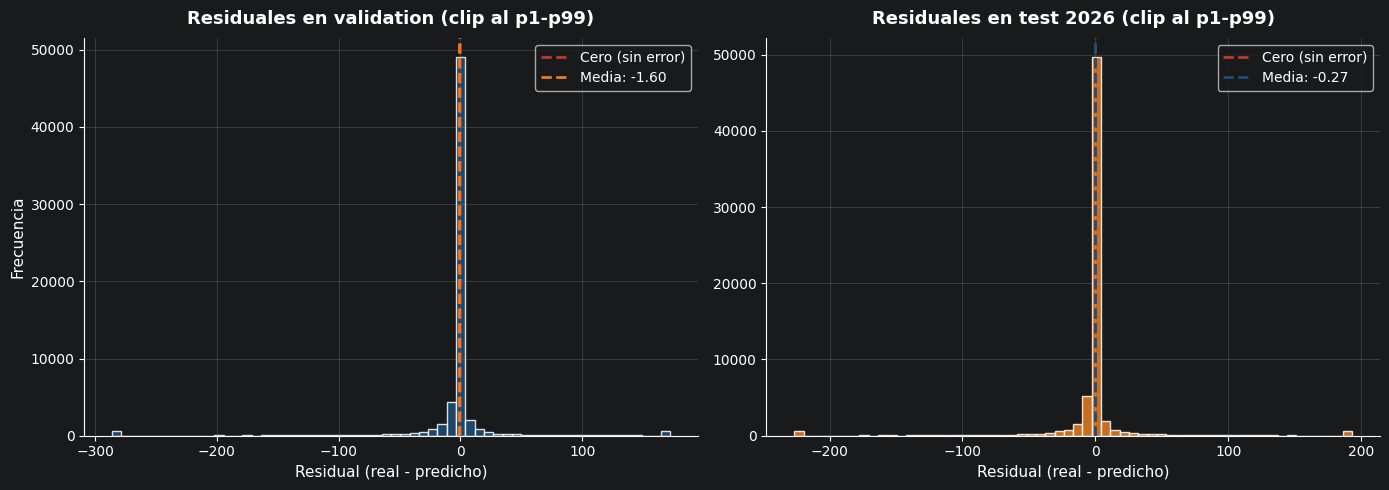

In [20]:
# Visualizar distribucion de residuales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation
res_v = valid["residual"]
p99_v = res_v.quantile(0.99)
p01_v = res_v.quantile(0.01)
axes[0].hist(res_v.clip(p01_v, p99_v), bins=60, color=COLOR_PRIMARIO,
              edgecolor="white", alpha=0.85)
axes[0].axvline(0, color=COLOR_ROJO, linestyle="--", linewidth=2, label="Cero (sin error)")
axes[0].axvline(res_v.mean(), color=COLOR_SECUNDARIO, linestyle="--",
                 linewidth=2, label=f"Media: {res_v.mean():.2f}")
axes[0].set_title(f"Residuales en validation (clip al p1-p99)", pad=10)
axes[0].set_xlabel("Residual (real - predicho)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Test 2026
res_t = test_2026["residual"]
p99_t = res_t.quantile(0.99)
p01_t = res_t.quantile(0.01)
axes[1].hist(res_t.clip(p01_t, p99_t), bins=60, color=COLOR_SECUNDARIO,
              edgecolor="white", alpha=0.85)
axes[1].axvline(0, color=COLOR_ROJO, linestyle="--", linewidth=2, label="Cero (sin error)")
axes[1].axvline(res_t.mean(), color=COLOR_PRIMARIO, linestyle="--",
                 linewidth=2, label=f"Media: {res_t.mean():.2f}")
axes[1].set_title(f"Residuales en test 2026 (clip al p1-p99)", pad=10)
axes[1].set_xlabel("Residual (real - predicho)")
axes[1].legend()

plt.tight_layout()
guardar(fig, "02_residuales")
€plt.show()

## 11. Visualizaciones — Real vs Predicho para SKUs top

Para sustentación y validación cualitativa: ¿qué tan bien sigue el baseline a los SKUs estrella?

  Guardado: reports/figures/baseline/03_real_vs_pred_top_skus.png


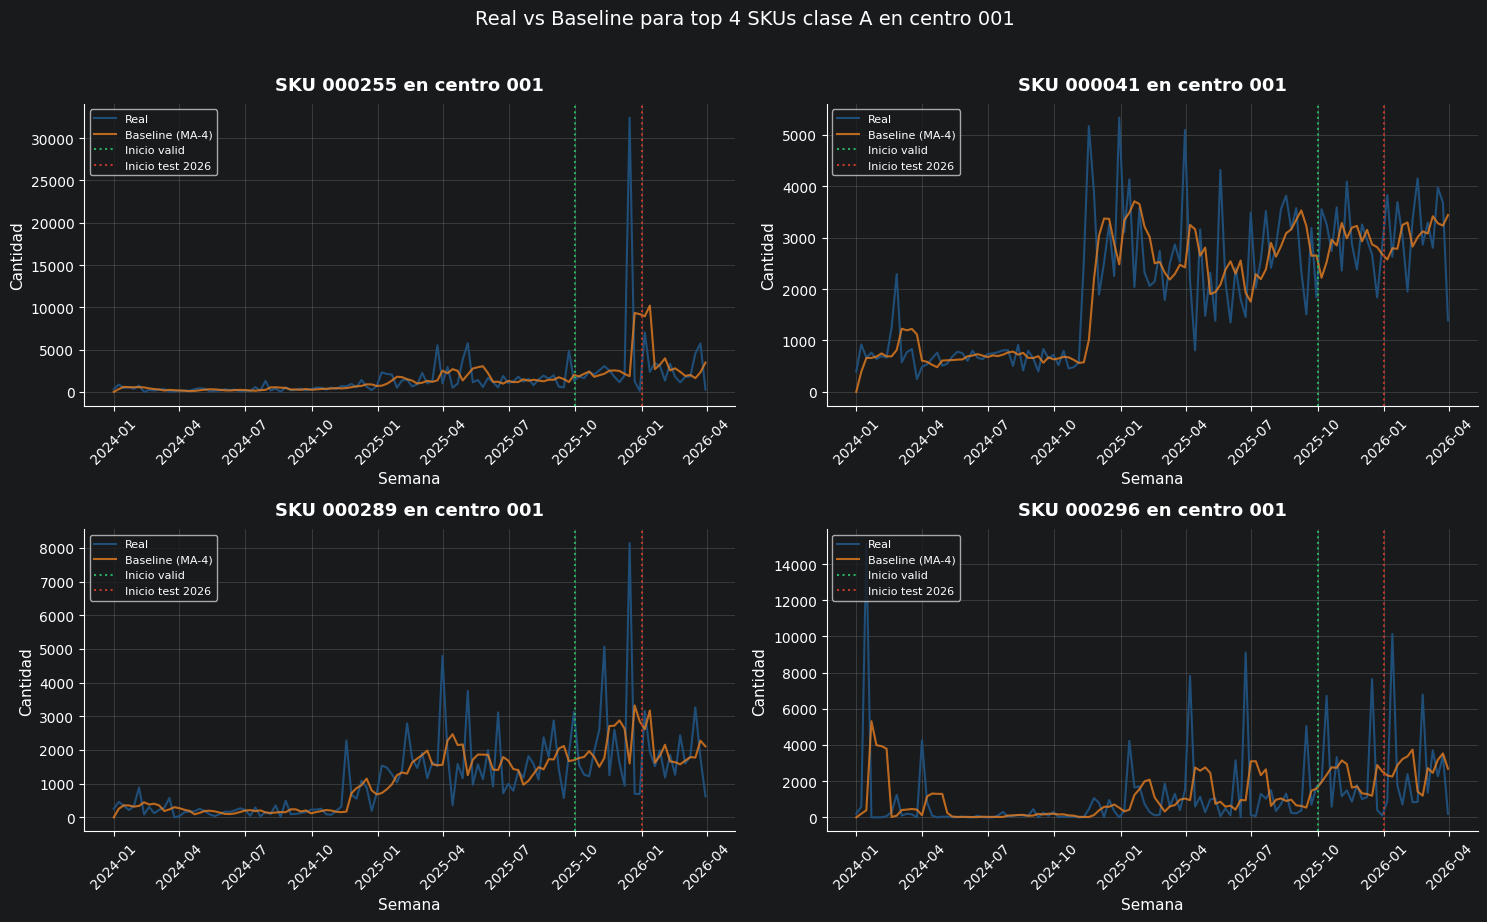

In [21]:
# Top 4 SKUs clase A (los mas importantes) en el centro 001
top_skus = (
    valid_clas[(valid_clas["clase_abc"] == "A") & (valid_clas["centro_operacion"] == "001")]
    .groupby("item")["y_real"].sum()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

# Tomar las series completas (train + valid + test_2026) para esos SKUs en centro 001
sub = dataset[
    (dataset["item"].isin(top_skus)) &
    (dataset["centro_operacion"] == "001")
].copy().sort_values(["item", "fecha_inicio_semana"])

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, sku in enumerate(top_skus):
    ax = axes[i]
    serie_sku = sub[sub["item"] == sku]

    # Plot real
    ax.plot(serie_sku["fecha_inicio_semana"], serie_sku["y_real"],
            label="Real", color=COLOR_PRIMARIO, linewidth=1.5)
    # Plot baseline
    ax.plot(serie_sku["fecha_inicio_semana"], serie_sku["y_pred_baseline"],
            label="Baseline (MA-4)", color=COLOR_SECUNDARIO, linewidth=1.5, alpha=0.8)

    # Marcar limite train/valid
    ax.axvline(pd.Timestamp("2025-10-01"), color=COLOR_VERDE, linestyle=":",
                linewidth=1.5, label="Inicio valid")
    ax.axvline(pd.Timestamp("2026-01-01"), color=COLOR_ROJO, linestyle=":",
                linewidth=1.5, label="Inicio test 2026")

    ax.set_title(f"SKU {sku} en centro 001", pad=10)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Cantidad")
    ax.legend(loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Real vs Baseline para top 4 SKUs clase A en centro 001", y=1.02, fontsize=14)
plt.tight_layout()
guardar(fig, "03_real_vs_pred_top_skus")
plt.show()

## 12. Guardado de predicciones y métricas en MySQL

Las predicciones del baseline y sus métricas se guardan en MySQL para poder compararlas en el notebook 09 (evaluación final) con los modelos siguientes.

In [22]:
# Construir tabla de pronosticos del baseline
pronosticos_baseline = pd.concat([
    valid[["item", "centro_operacion", "fecha_inicio_semana", "y_real", "y_pred_baseline"]]
    .assign(split="valid", modelo="baseline_ma4"),
    test_2026[["item", "centro_operacion", "fecha_inicio_semana", "y_real", "y_pred_baseline"]]
    .assign(split="test_2026", modelo="baseline_ma4"),
])
pronosticos_baseline = pronosticos_baseline.rename(columns={
    "y_real": "cantidad_real",
    "y_pred_baseline": "cantidad_predicha",
})

print(f"Pronosticos del baseline a guardar: {len(pronosticos_baseline):,} filas")

Pronosticos del baseline a guardar: 131,185 filas


In [26]:
# Forzar recreacion de la tabla pronosticos con el esquema correcto
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS pronosticos"))
    conn.execute(text("""
        CREATE TABLE pronosticos (
            item VARCHAR(30),
            centro_operacion VARCHAR(10),
            fecha_inicio_semana DATE,
            cantidad_real DECIMAL(18,4),
            cantidad_predicha DECIMAL(18,4),
            split VARCHAR(20),
            modelo VARCHAR(50),
            INDEX idx_item (item),
            INDEX idx_modelo (modelo),
            INDEX idx_split (split)
        )
    """))
    print("Tabla pronosticos recreada con esquema correcto.")

# Guardar en chunks de 1000 sin method="multi"
print(f"\nGuardando {len(pronosticos_baseline):,} filas en chunks de 1000...")
pronosticos_baseline.to_sql(
    "pronosticos",
    engine,
    if_exists="append",
    index=False,
    chunksize=1000,
)

with engine.connect() as conn:
    n = conn.execute(text("SELECT COUNT(*) FROM pronosticos WHERE modelo='baseline_ma4'")).scalar()
print(f"\nTabla pronosticos: {n:,} filas del baseline guardadas.")

Tabla pronosticos recreada con esquema correcto.

Guardando 131,185 filas en chunks de 1000...

Tabla pronosticos: 131,185 filas del baseline guardadas.


In [28]:
# Forzar recreacion de la tabla metricas_modelos
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS metricas_modelos"))
    conn.execute(text("""
        CREATE TABLE metricas_modelos (
            modelo VARCHAR(50),
            split VARCHAR(20),
            segmento VARCHAR(20),
            mae DECIMAL(18,6),
            rmse DECIMAL(18,6),
            mape DECIMAL(18,6),
            smape DECIMAL(18,6),
            n_obs INT
        )
    """))

metricas_resumen.to_sql("metricas_modelos", engine, if_exists="append", index=False)
print(f"Metricas guardadas: {len(metricas_resumen)} filas en tabla metricas_modelos.")
metricas_resumen

Metricas guardadas: 2 filas en tabla metricas_modelos.


,modelo,split,segmento,mae,rmse,mape,smape,n_obs
0,baseline_ma4,valid,global,37.0883,494.2920,180.4292,146.3193,64613
1,baseline_ma4,test_2026,global,32.4968,389.0088,170.6220,147.7178,66572


## 13. Resumen y conclusiones

### 13.1 ¿Qué hicimos?

Construimos un modelo de referencia (baseline) que predice la cantidad de cada SKU × centro × semana como el promedio de las 4 semanas anteriores. Evaluamos su desempeño en dos conjuntos:

- **Validation** (Q4 2025): 64.613 observaciones.
- **Test 2026** (Q1 2026): 66.572 observaciones.

### 13.2 Lectura de los números

- **MAE** = error absoluto promedio en unidades reales. Es directamente interpretable: "el baseline se equivoca por X unidades en promedio".
- **El baseline tiene un MAE distinto por segmento ABC/XYZ**, lo que confirma que la dificultad del problema varía según el tipo de SKU.

### 13.3 Lo que viene

Los modelos siguientes (LightGBM, XGBoost, Prophet) **deben superar al baseline** para justificar su uso. Si no lo hacen, el baseline es la solución óptima del proyecto.

- **Notebook 06 — LightGBM:** modelo principal del proyecto, debería mejorar al baseline.
- **Notebook 07 — XGBoost:** comparación.
- **Notebook 08 — Prophet:** para top 50 SKUs clase A.
- **Notebook 09 — Evaluación final:** comparación lado a lado de todos los modelos.

In [29]:
print("=" * 65)
print("BASELINE (media movil 4 semanas) — RESUMEN FINAL")
print("=" * 65)
print()
print(f"{'Metrica':<10} {'Validation':>15} {'Test 2026':>15}")
print("-" * 65)
for m in ["mae", "rmse", "mape", "smape"]:
    sufijo = "%" if m in ["mape", "smape"] else ""
    print(f"{m.upper():<10} {metricas_valid[m]:>14.4f}{sufijo}  {metricas_test[m]:>14.4f}{sufijo}")
print()
print("Tablas MySQL actualizadas:")
print(f"  - pronosticos (modelo='baseline_ma4'): {len(pronosticos_baseline):,} filas")
print(f"  - metricas_modelos (modelo='baseline_ma4'): {len(metricas_resumen)} filas")
print()
print("Siguiente paso: notebook 06 (LightGBM) — debe MEJORAR estos numeros.")
print("=" * 65)

BASELINE (media movil 4 semanas) — RESUMEN FINAL

Metrica         Validation       Test 2026
-----------------------------------------------------------------
MAE               37.0883         32.4968
RMSE             494.2920        389.0088
MAPE             180.4292%        170.6220%
SMAPE            146.3193%        147.7178%

Tablas MySQL actualizadas:
  - pronosticos (modelo='baseline_ma4'): 131,185 filas
  - metricas_modelos (modelo='baseline_ma4'): 2 filas

Siguiente paso: notebook 06 (LightGBM) — debe MEJORAR estos numeros.
